已保存注入噪声后的结果图至: result_injected_noise.png
已保存对比可视化分析图至: comparison_visualization.png


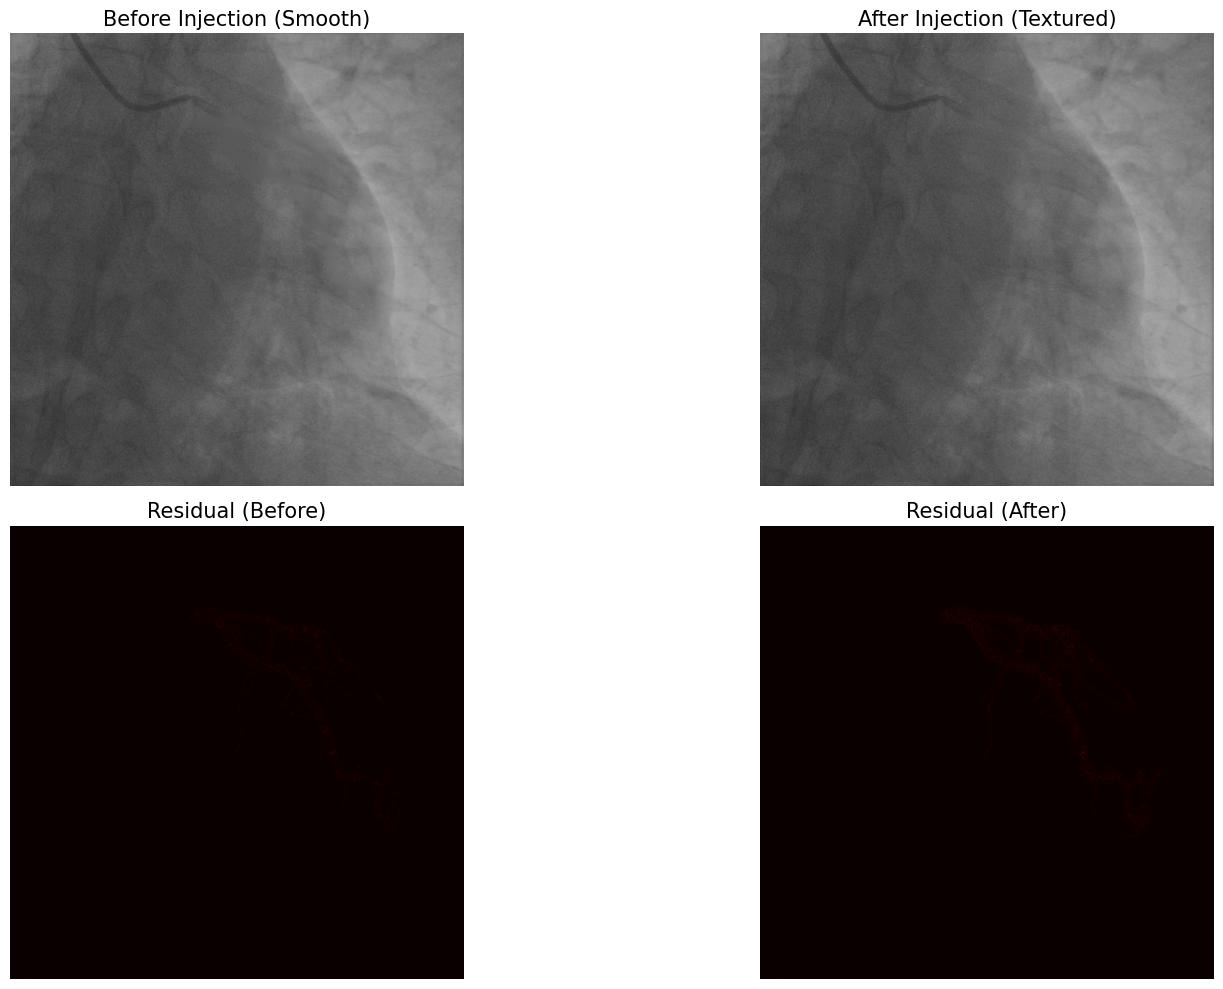

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def inject_physics_noise_gray(restored_img, mask, alpha=0.03, beta=0.005):
    # 确保输入是单通道灰度图
    if len(restored_img.shape) == 3:
        gray_img = cv2.cvtColor(restored_img, cv2.COLOR_BGR2GRAY)
    else:
        gray_img = restored_img.copy()
        
    img_f = gray_img.astype(np.float32) / 255.0
    mask_f = mask.astype(np.float32) / 255.0
    if len(mask_f.shape) == 3:
        mask_f = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # 物理噪声模型: sigma^2 = alpha * I + beta (单通道计算)
    sigma = np.sqrt(alpha * img_f + beta)
    noise = np.random.normal(0, 1, img_f.shape).astype(np.float32)
    
    # 在 Mask 区域调制并注入
    noisy_patch = img_f + noise * sigma
    mask_soft = cv2.GaussianBlur(mask_f, (15, 15), 0) # 增大核使边缘更自然
    
    result_f = img_f * (1 - mask_soft) + noisy_patch * mask_soft
    result_u8 = np.clip(result_f * 255, 0, 255).astype(np.uint8)
    
    return result_u8

def inject_physics_noise_refined(restored_img, mask, alpha=0.0001, beta=0.0001, noise_grain=0.05):
    """
    alpha: 降低增益，减少黑白斑点感
    beta: 基础噪声
    noise_grain: 噪声颗粒度，值越大，噪声越模糊（越接近真实探测器效果）
    """
    img_f = restored_img.astype(np.float32) / 255.0
    mask_f = mask.astype(np.float32) / 255.0
    if len(mask_f.shape) == 3:
        mask_f = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # 1. 核心改进：根据亮度计算标准差，控制噪声幅度
    sigma = np.sqrt(alpha * img_f + beta)
    
    # 2. 生成随机噪声
    noise = np.random.normal(0, 1, img_f.shape).astype(np.float32)
    
    # 3. 核心改进：对噪声进行平滑处理，使其具有“颗粒感”而非“像素点感”
    if noise_grain > 0:
        noise = cv2.GaussianBlur(noise, (0, 0), sigmaX=noise_grain)
        # 平滑后方差会下降，需要补偿增益以维持量级
        noise = noise * 1.4 

    # 4. 注入并混合
    noisy_patch = img_f + noise * sigma
    mask_soft = cv2.GaussianBlur(mask_f, (21, 21), 0) # 进一步软化边缘
    
    result_f = img_f * (1 - mask_soft) + noisy_patch * mask_soft
    return np.clip(result_f * 255, 0, 255).astype(np.uint8)

    # 建议参数尝试：alpha=0.005, noise_grain=0.5

def process_and_save(original, restored, mask):
    # 读取图片
    # original = cv2.imread(original_path, 0) # 直接以灰度模式读取
    # restored = cv2.imread(restored_path, 0)
    # mask = cv2.imread(mask_path, 0)

    # 执行注入
    # alpha 越大，颗粒感越重；beta 控制暗部基础噪声
    injected = inject_physics_noise_refined(restored, mask, alpha=0.0001, beta=0.0001, noise_grain=0.05)

    # 1. 保存最终的去血管背景图
    cv2.imwrite('result_injected_noise.png', injected)
    print("已保存注入噪声后的结果图至: result_injected_noise.png")

    # 2. 生成对比可视化并保存
    plt.figure(figsize=(18, 10))
    
    # 计算差分图 (DSA 模拟)
    diff_before = cv2.absdiff(original, restored)
    diff_after = cv2.absdiff(original, injected)

    display_list = [
        (restored, 'Before Injection (Smooth)'),
        (injected, 'After Injection (Textured)'),
        (diff_before, 'Residual (Before)'),
        (diff_after, 'Residual (After)')
    ]

    for i, (img, title) in enumerate(display_list):
        plt.subplot(2, 2, i+1)
        # 结果图用灰度显示，差分图用 hot 强化显示轮廓残留
        cmap = 'gray' if i < 2 else 'hot'
        plt.imshow(img, cmap=cmap, vmin=0, vmax=255)
        plt.title(title, fontsize=15)
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('comparison_visualization.png', dpi=300)
    print("已保存对比可视化分析图至: comparison_visualization.png")
    plt.show()

# 使用时请确保文件名正确
# process_and_save('original.jpg', 'restored.jpg', 'mask.png')

# 调用示例 (替换为你的文件名)
orig = cv2.imread('/home/share/clr/share/data/cag_res_v2/test/test_C/cag1-l1-c102s11f0-c96s1f27.png', 0)
rest = cv2.imread('/home/share/clr/share/work/CAGSubtraction/ShadowFormer/results_bak/cag1-l1-c102s11f0-c96s1f27.png', 0)
msk = cv2.imread('/home/share/clr/share/data/cag_res_v2/test/test_B/cag1-l1-c102s11f0-c96s1f27.png', 0)
process_and_save(orig, rest, msk)

In [2]:
!pwd

/home/share/clr/share/work/CAGSubtraction/ShadowFormer


In [4]:
!ls /home/share/clr/share/work/CAGSubtraction/ShadowFormer/results_res_v2_test_256/L_IM000079_5_1.png

/home/share/clr/share/work/CAGSubtraction/ShadowFormer/results_res_v2_test_256/L_IM000079_5_1.png
